# Week 3 · Task 1 — Simulate each distribution, compare with theory

**Roadmap task:** *Simulate each distribution and plot your simulation against the theoretical curve.*

The five distributions that actually appear in data science: **Bernoulli, Binomial, Poisson, Normal, Exponential**.
The theoretical formulas are written by hand in `mathkit/distributions.py` (and tested against `scipy.stats`).

**What this notebook shows**

1. For each distribution: what story it describes, its formula, a simulation vs the formula, and mean/variance checked.
2. How they are **connected** — Bernoulli → Binomial → Poisson → Exponential — so you remember one family, not five facts.
3. How a computer makes exponential random numbers out of uniform ones (inverse-transform sampling).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from mathkit.distributions import (bernoulli_pmf, binomial_pmf, poisson_pmf, normal_pdf,
                                   exponential_pdf, exponential_via_inverse_transform)

FIG = pathlib.Path("figures"); FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(42)
N = 100_000          # simulated draws per distribution

## 1. The cheat-sheet

| distribution | story (in simple words) | formula | mean | variance | where you meet it |
|---|---|---|---|---|---|
| **Bernoulli($p$)** | one coin flip, P(heads) = $p$ | $P(1)=p,\;P(0)=1-p$ | $p$ | $p(1-p)$ | a click / no-click; the output of logistic regression (Week 11) |
| **Binomial($n,p$)** | number of heads in $n$ independent flips | $\binom{n}{k}p^k(1-p)^{n-k}$ | $np$ | $np(1-p)$ | conversions out of $n$ visitors in an A/B test (Week 17) |
| **Poisson($\lambda$)** | number of events in a fixed window, when events are rare and independent | $\dfrac{\lambda^k e^{-\lambda}}{k!}$ | $\lambda$ | $\lambda$ | orders per hour, website errors per day |
| **Normal($\mu,\sigma$)** | the sum of many small independent effects | $\dfrac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$ | $\mu$ | $\sigma^2$ | measurement noise; sampling distributions (CLT, next notebook) |
| **Exponential($\lambda$)** | waiting time until the next Poisson event | $\lambda e^{-\lambda x},\;x\ge 0$ | $1/\lambda$ | $1/\lambda^2$ | time between customer arrivals, time to failure |

## 2. Simulate all five and overlay the formula

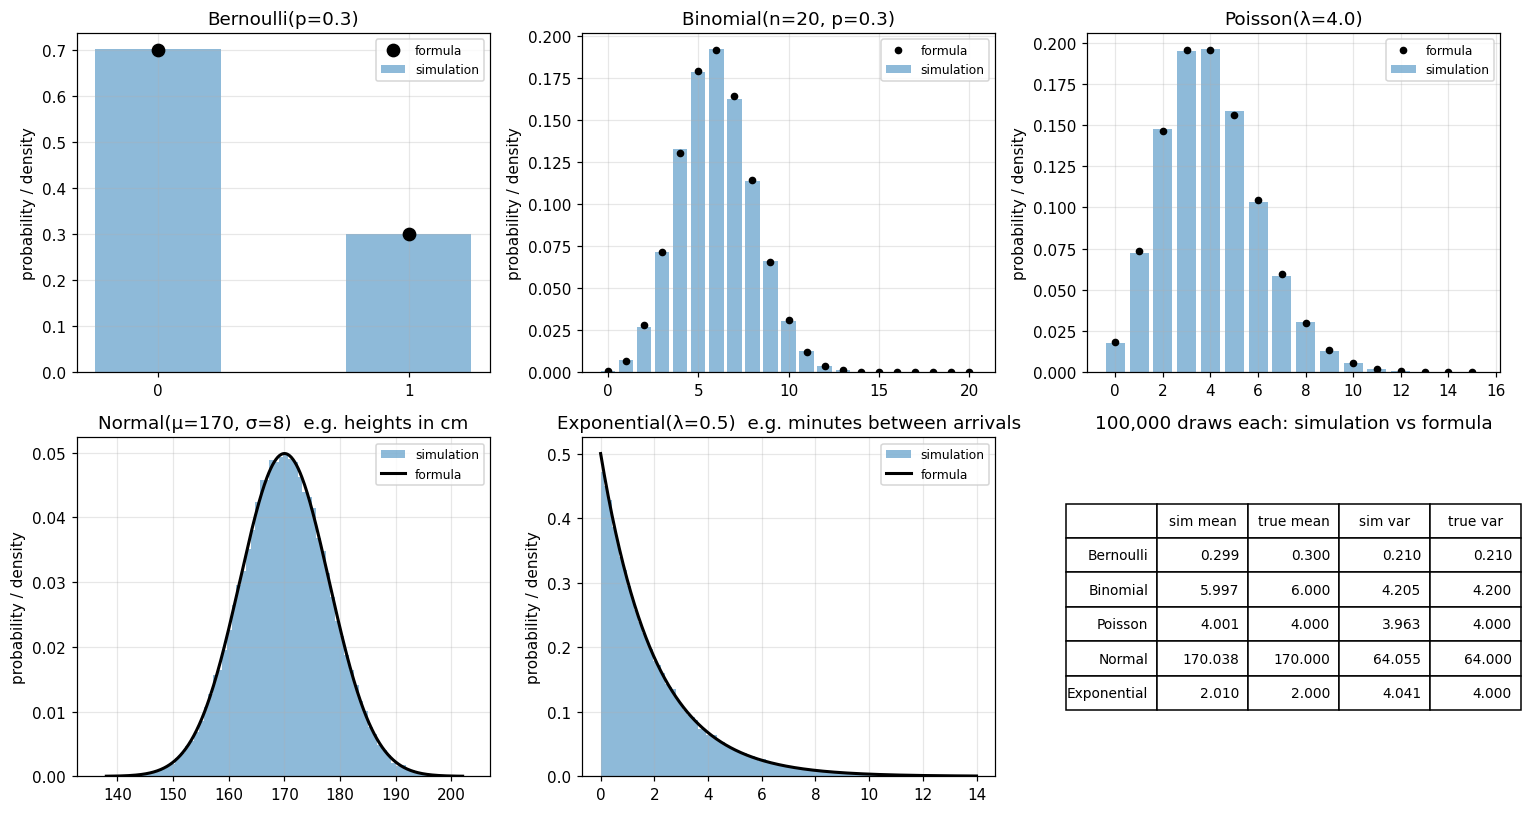

In [2]:
p, n, lam, mu, sigma, rate = 0.3, 20, 4.0, 170, 8, 0.5
samples = {
    "Bernoulli": rng.random(N) < p,                 # built from uniform numbers: "is U < p?"
    "Binomial":  rng.binomial(n, p, N),
    "Poisson":   rng.poisson(lam, N),
    "Normal":    rng.normal(mu, sigma, N),
    "Exponential": rng.exponential(1 / rate, N),     # NumPy uses scale = 1/lambda
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
ax = axes[0, 0]
k = np.array([0, 1]); freq = np.bincount(samples["Bernoulli"].astype(int), minlength=2) / N
ax.bar(k, freq, width=0.5, alpha=0.5, label="simulation"); ax.plot(k, bernoulli_pmf(k, p), "ko", ms=8, label="formula")
ax.set_xticks([0, 1]); ax.set_title(f"Bernoulli(p={p})")

ax = axes[0, 1]
k = np.arange(0, n + 1); freq = np.bincount(samples["Binomial"], minlength=n + 1)[: n + 1] / N
ax.bar(k, freq, alpha=0.5, label="simulation"); ax.plot(k, binomial_pmf(k, n, p), "ko", ms=4, label="formula")
ax.set_title(f"Binomial(n={n}, p={p})")

ax = axes[0, 2]
k = np.arange(0, 16); freq = np.bincount(samples["Poisson"], minlength=16)[:16] / N
ax.bar(k, freq, alpha=0.5, label="simulation"); ax.plot(k, poisson_pmf(k, lam), "ko", ms=4, label="formula")
ax.set_title(f"Poisson(λ={lam})")

ax = axes[1, 0]
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 400)
ax.hist(samples["Normal"], bins=80, density=True, alpha=0.5, label="simulation")
ax.plot(x, normal_pdf(x, mu, sigma), "k", lw=2, label="formula"); ax.set_title(f"Normal(μ={mu}, σ={sigma})  e.g. heights in cm")

ax = axes[1, 1]
x = np.linspace(0, 14, 400)
ax.hist(samples["Exponential"], bins=100, range=(0, 14), density=True, alpha=0.5, label="simulation")
ax.plot(x, exponential_pdf(x, rate), "k", lw=2, label="formula"); ax.set_title(f"Exponential(λ={rate})  e.g. minutes between arrivals")

for a in axes.flat[:5]:
    a.set_ylabel("probability / density"); a.legend(fontsize=8)

# summary table in the 6th panel
ax = axes[1, 2]; ax.axis("off")
theory = {"Bernoulli": (p, p * (1 - p)), "Binomial": (n * p, n * p * (1 - p)), "Poisson": (lam, lam),
          "Normal": (mu, sigma ** 2), "Exponential": (1 / rate, 1 / rate ** 2)}
rows = [[name, f"{samples[name].mean():.3f}", f"{m:.3f}", f"{samples[name].var():.3f}", f"{v:.3f}"]
        for name, (m, v) in theory.items()]
tbl = ax.table(cellText=rows, colLabels=["", "sim mean", "true mean", "sim var", "true var"], loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.1, 1.6)
ax.set_title(f"{N:,} draws each: simulation vs formula")

fig.tight_layout(); fig.savefig(FIG / "w3_distributions.png", dpi=150); plt.show()

Every simulation lands on its formula, and every simulated mean and variance matches the theory to 2–3 decimal places. The small remaining gaps are **sampling noise**, and they shrink like $1/\sqrt{N}$ — you'll meet that $\sqrt{N}$ again as the *standard error* in Week 4.

## 3. They are one family, not five facts

**Bernoulli → Binomial.** A Binomial is literally a *sum of $n$ Bernoullis*. Let's build it that way instead of calling `rng.binomial`:

In [3]:
flips = rng.random((N, n)) < p          # N experiments, each with n coin flips
built_binomial = flips.sum(axis=1)       # count the heads in each experiment
print("Binomial built from Bernoullis: mean", built_binomial.mean().round(3), " var", built_binomial.var().round(3),
      "  (theory", n * p, ",", round(n * p * (1 - p), 3), ")")
print("Why the variance is np(1-p): variances of INDEPENDENT things add ->  n × p(1-p)")

Binomial built from Bernoullis: mean 6.005  var 4.181   (theory 6.0 , 4.2 )
Why the variance is np(1-p): variances of INDEPENDENT things add ->  n × p(1-p)


**Binomial → Poisson.** Take many trials ($n$ large) with a tiny chance each ($p$ small), keeping the average $np = \lambda$ fixed. The Binomial turns into the Poisson. Example: 10,000 website visitors, each with a 0.04% chance of hitting an error → about 4 errors a day, Poisson(4).

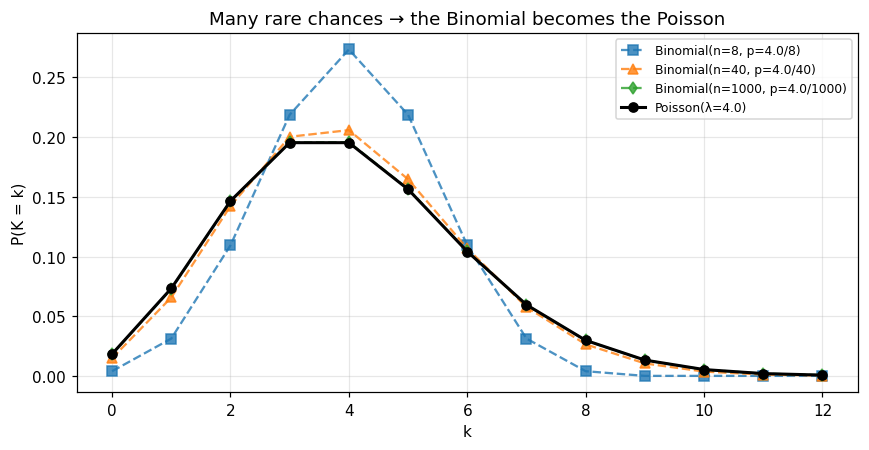

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.2))
k = np.arange(0, 13)
for n_trials, style in [(8, "s--"), (40, "^--"), (1000, "d--")]:
    ax.plot(k, binomial_pmf(k, n_trials, lam / n_trials), style, alpha=0.8, label=f"Binomial(n={n_trials}, p={lam}/{n_trials})")
ax.plot(k, poisson_pmf(k, lam), "ko-", lw=2, label=f"Poisson(λ={lam})")
ax.set_xlabel("k"); ax.set_ylabel("P(K = k)"); ax.legend(fontsize=8)
ax.set_title("Many rare chances → the Binomial becomes the Poisson")
fig.tight_layout(); fig.savefig(FIG / "w3_binomial_to_poisson.png", dpi=150); plt.show()

**Poisson → Exponential.** If events arrive as a Poisson process with rate $\lambda$ per minute, the **gap between consecutive events** is Exponential($\lambda$). Let's simulate a stream of events minute by minute (tiny time slices, each with a small chance of an event) and measure the gaps:

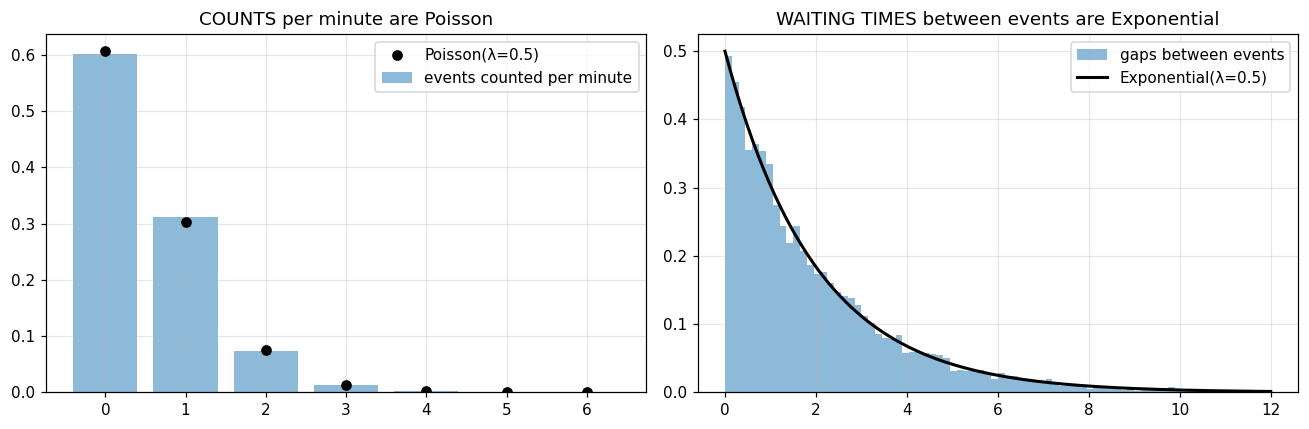

mean gap = 1.983 minutes   (theory 1/λ = 2.0)


In [5]:
dt = 0.001                                           # time slice of 1/1000 of a minute
events = rng.random(int(20_000 / dt)) < rate * dt    # 20,000 minutes of "does an event happen now?"
times = np.flatnonzero(events) * dt
gaps = np.diff(times)
counts_per_minute = np.bincount(times.astype(int))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
k = np.arange(0, 7)
axes[0].bar(k, np.bincount(counts_per_minute, minlength=7)[:7] / len(counts_per_minute), alpha=0.5, label="events counted per minute")
axes[0].plot(k, poisson_pmf(k, rate), "ko", label=f"Poisson(λ={rate})"); axes[0].legend(); axes[0].set_title("COUNTS per minute are Poisson")
x = np.linspace(0, 12, 300)
axes[1].hist(gaps, bins=80, range=(0, 12), density=True, alpha=0.5, label="gaps between events")
axes[1].plot(x, exponential_pdf(x, rate), "k", lw=2, label=f"Exponential(λ={rate})"); axes[1].legend()
axes[1].set_title("WAITING TIMES between events are Exponential")
fig.tight_layout(); fig.savefig(FIG / "w3_poisson_exponential.png", dpi=150); plt.show()
print(f"mean gap = {gaps.mean():.3f} minutes   (theory 1/λ = {1 / rate})")

One process, two questions: *"how many in a window?"* → Poisson. *"How long until the next one?"* → Exponential.

## 4. How a computer makes exponential numbers (inverse transform)

Computers really only generate **uniform** numbers $U$ between 0 and 1. To get an exponential:

1. The exponential CDF is $F(x) = P(X \le x) = 1 - e^{-\lambda x}$.
2. Solve $u = F(x)$ for $x$: $\;x = -\ln(1-u)/\lambda$.
3. Feed uniform numbers through that formula.

Why it works: $P(X \le x) = P\!\left(U \le 1-e^{-\lambda x}\right) = 1-e^{-\lambda x}$ — exactly the exponential CDF. This trick works for any distribution whose CDF you can invert.

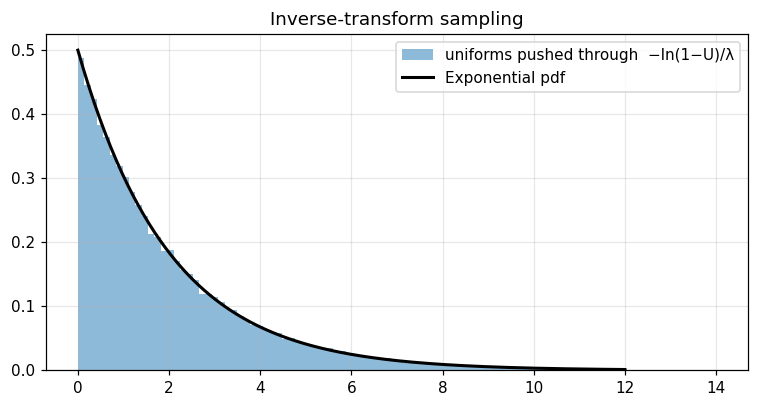

mean 2.003 (theory 2.0),  var 3.988 (theory 4.0)


In [6]:
mine = exponential_via_inverse_transform(rate, N, rng)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(mine, bins=100, range=(0, 14), density=True, alpha=0.5, label="uniforms pushed through  −ln(1−U)/λ")
ax.plot(x, exponential_pdf(x, rate), "k", lw=2, label="Exponential pdf")
ax.set_title("Inverse-transform sampling"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "w3_inverse_transform.png", dpi=150); plt.show()
print(f"mean {mine.mean():.3f} (theory {1/rate}),  var {mine.var():.3f} (theory {1/rate**2})")

## 5. Your turn

1. By hand: for Binomial($n=5$, $p=0.5$), compute $P(K=2)$. (Answer: $10/32 = 0.3125$.) Check with `binomial_pmf`.
2. A shop gets on average 3 customers per 10 minutes. What is $P(\text{no customers in 10 minutes})$? Compute with the Poisson formula, then **verify by simulation**.
3. The Normal has two parameters, the Poisson only one. What does it mean that the Poisson's mean and variance are always equal? Find a real dataset where counts have variance ≫ mean ("over-dispersion") — Poisson would be the wrong model.
4. **Explain out loud:** "What's the difference between a probability mass function and a probability density function? Why can a density be bigger than 1?"